# Building and Properties Violations Dataset Cleaning

In [2]:
import pandas as pd 
import numpy as np

Extract the csv file from https://data.boston.gov/dataset/building-and-property-violations1/resource/800a2663-1d6a-46e7-9356-bedb70f5332c

In [3]:
# Read csv file 

df2 = pd.read_csv('tmp_y61o6kg.csv')
df2

,case_no,ap_case_defn_key,status_dttm,status,code,value,description,violation_stno,violation_sthigh,violation_street,...,ward,contact_addr1,contact_addr2,contact_city,contact_state,contact_zip,sam_id,latitude,longitude,location
0,V91983,1013,NaN,Closed,121.2,NaN,Unsafe and Dangerous,302,NaN,Sumner,...,01,302 Sumner St,NaN,East Boston,MA,02128,132380.0,42.367678,-71.036580,"(42.367678491544524, -71.03658037747812)"
1,V791547,1013,2024-10-02 12:44:50,Open,105.1,NaN,Failure to Obtain Permit,198,NaN,Orient,...,01,198 ORIENT AVE #1,NaN,EAST BOSTON,MA,02128,105591.0,42.390709,-71.008250,"(42.39070945439699, -71.00825026256047)"
2,V791539,1013,2024-10-02 12:31:27,Open,105.1,NaN,Failure to Obtain Permit,49,,Hooker,...,22,281 CHOOL ST,NaN,WATERTOWN,MA,02472,75177.0,42.358320,-71.128061,"(42.35831961100101, -71.12806060364741)"
3,V791518,1013,2024-10-02 11:30:41,Open,105.1,NaN,Failure to Obtain Permit,45,NaN,Stanbro,...,18,45 STANBRO ST,NaN,HYDE PARK,MA,02136,130097.0,42.234600,-71.130061,"(42.23459970816364, -71.13006086425501)"
4,V296634,1013,2024-10-01 11:23:51,Closed,105.1,NaN,Failure to Obtain Permit,1724,1740,Dorchester,...,16,1759 Dorchester Avenue,NaN,Dorchester,MA,02124,48395.0,42.291130,-71.062621,"(42.29112953157363, -71.06262060649728)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16250,V53371,1013,2009-12-03 11:26:33,Closed,103,NaN,Maintenance,55,NaN,Fenwood,...,10,2 NEW WHITNEY ST,NaN,BOSTON,MA,02115,57589.0,42.335320,-71.107611,"(42.33531958775082, -71.10761060896684)"
16251,V53076,1013,2009-12-03 10:01:21,Closed,110.1,NaN,Inspections,225,NaN,Chelsea,...,01,45 FALCON ST,NaN,EAST BOSTON,MA,02128,30417.0,42.375199,-71.032310,"(42.375199485231036, -71.03231035124385)"
16252,V53175,1013,2009-12-02 11:32:46,Closed,110.1,NaN,Inspections,2,,French,...,10,2 FRENCH TER,NaN,ROXBURY CROSSING,MA,02120,NaN,42.330640,-71.097051,"(42.330639573986325, -71.09705059581793)"
16253,V53078,1013,2009-12-01 13:39:34,Closed,110.1,NaN,Inspections,1670,NaN,Washington,...,08,1670 WASHINGTON ST,NaN,BOSTON,MA,02118,144315.0,42.337380,-71.075271,"(42.33737954420211, -71.07527053204305)"


In [4]:
df2["sam_id"].value_counts()

sam_id
0.0         146
143328.0     22
166058.0     19
129629.0     18
145249.0     18
           ... 
106467.0      1
165216.0      1
103598.0      1
83967.0       1
42951.0       1
Name: count, Length: 10079, dtype: int64

In [5]:
df2.columns

Index(['case_no', 'ap_case_defn_key', 'status_dttm', 'status', 'code', 'value',
       'description', 'violation_stno', 'violation_sthigh', 'violation_street',
       'violation_suffix', 'violation_city', 'violation_state',
       'violation_zip', 'ward', 'contact_addr1', 'contact_addr2',
       'contact_city', 'contact_state', 'contact_zip', 'sam_id', 'latitude',
       'longitude', 'location'],
      dtype='object')

The values column is empty for all entries so we will remove it from the dataframe

In [6]:
df3 = df2.drop(columns=['value'])
df3

,case_no,ap_case_defn_key,status_dttm,status,code,description,violation_stno,violation_sthigh,violation_street,violation_suffix,...,ward,contact_addr1,contact_addr2,contact_city,contact_state,contact_zip,sam_id,latitude,longitude,location
0,V91983,1013,NaN,Closed,121.2,Unsafe and Dangerous,302,NaN,Sumner,ST,...,01,302 Sumner St,NaN,East Boston,MA,02128,132380.0,42.367678,-71.036580,"(42.367678491544524, -71.03658037747812)"
1,V791547,1013,2024-10-02 12:44:50,Open,105.1,Failure to Obtain Permit,198,NaN,Orient,AVE,...,01,198 ORIENT AVE #1,NaN,EAST BOSTON,MA,02128,105591.0,42.390709,-71.008250,"(42.39070945439699, -71.00825026256047)"
2,V791539,1013,2024-10-02 12:31:27,Open,105.1,Failure to Obtain Permit,49,,Hooker,ST,...,22,281 CHOOL ST,NaN,WATERTOWN,MA,02472,75177.0,42.358320,-71.128061,"(42.35831961100101, -71.12806060364741)"
3,V791518,1013,2024-10-02 11:30:41,Open,105.1,Failure to Obtain Permit,45,NaN,Stanbro,ST,...,18,45 STANBRO ST,NaN,HYDE PARK,MA,02136,130097.0,42.234600,-71.130061,"(42.23459970816364, -71.13006086425501)"
4,V296634,1013,2024-10-01 11:23:51,Closed,105.1,Failure to Obtain Permit,1724,1740,Dorchester,AVE,...,16,1759 Dorchester Avenue,NaN,Dorchester,MA,02124,48395.0,42.291130,-71.062621,"(42.29112953157363, -71.06262060649728)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16250,V53371,1013,2009-12-03 11:26:33,Closed,103,Maintenance,55,NaN,Fenwood,RD,...,10,2 NEW WHITNEY ST,NaN,BOSTON,MA,02115,57589.0,42.335320,-71.107611,"(42.33531958775082, -71.10761060896684)"
16251,V53076,1013,2009-12-03 10:01:21,Closed,110.1,Inspections,225,NaN,Chelsea,ST,...,01,45 FALCON ST,NaN,EAST BOSTON,MA,02128,30417.0,42.375199,-71.032310,"(42.375199485231036, -71.03231035124385)"
16252,V53175,1013,2009-12-02 11:32:46,Closed,110.1,Inspections,2,,French,TE,...,10,2 FRENCH TER,NaN,ROXBURY CROSSING,MA,02120,NaN,42.330640,-71.097051,"(42.330639573986325, -71.09705059581793)"
16253,V53078,1013,2009-12-01 13:39:34,Closed,110.1,Inspections,1670,NaN,Washington,ST,...,08,1670 WASHINGTON ST,NaN,BOSTON,MA,02118,144315.0,42.337380,-71.075271,"(42.33737954420211, -71.07527053204305)"


We are mainly focusing on the violation address, so we will remove entries with no violation address 

In [7]:
# Define the address columns
address_columns = ['violation_stno', 'violation_street', 'violation_suffix', 'violation_city']

# Strip any leading or trailing whitespace from the columns and replace empty strings with NaN
df3[address_columns] = df3[address_columns].apply(lambda col: col.str.strip().replace("", np.nan))

# Drop rows with any NaN values in the specified address columns
df3.dropna(subset=address_columns, inplace=True)

In [8]:
df4

NameError: name 'df4' is not defined

In [31]:
df3

,case_no,ap_case_defn_key,status_dttm,status,code,description,violation_stno,violation_sthigh,violation_street,violation_suffix,...,ward,contact_addr1,contact_addr2,contact_city,contact_state,contact_zip,sam_id,latitude,longitude,location
0,V91983,1013,NaN,Closed,121.2,Unsafe and Dangerous,302,NaN,Sumner,ST,...,01,302 Sumner St,NaN,East Boston,MA,02128,132380.0,42.367678,-71.036580,"(42.367678491544524, -71.03658037747812)"
1,V791547,1013,2024-10-02 12:44:50,Open,105.1,Failure to Obtain Permit,198,NaN,Orient,AVE,...,01,198 ORIENT AVE #1,NaN,EAST BOSTON,MA,02128,105591.0,42.390709,-71.008250,"(42.39070945439699, -71.00825026256047)"
2,V791539,1013,2024-10-02 12:31:27,Open,105.1,Failure to Obtain Permit,49,,Hooker,ST,...,22,281 CHOOL ST,NaN,WATERTOWN,MA,02472,75177.0,42.358320,-71.128061,"(42.35831961100101, -71.12806060364741)"
3,V791518,1013,2024-10-02 11:30:41,Open,105.1,Failure to Obtain Permit,45,NaN,Stanbro,ST,...,18,45 STANBRO ST,NaN,HYDE PARK,MA,02136,130097.0,42.234600,-71.130061,"(42.23459970816364, -71.13006086425501)"
4,V296634,1013,2024-10-01 11:23:51,Closed,105.1,Failure to Obtain Permit,1724,1740,Dorchester,AVE,...,16,1759 Dorchester Avenue,NaN,Dorchester,MA,02124,48395.0,42.291130,-71.062621,"(42.29112953157363, -71.06262060649728)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16250,V53371,1013,2009-12-03 11:26:33,Closed,103,Maintenance,55,NaN,Fenwood,RD,...,10,2 NEW WHITNEY ST,NaN,BOSTON,MA,02115,57589.0,42.335320,-71.107611,"(42.33531958775082, -71.10761060896684)"
16251,V53076,1013,2009-12-03 10:01:21,Closed,110.1,Inspections,225,NaN,Chelsea,ST,...,01,45 FALCON ST,NaN,EAST BOSTON,MA,02128,30417.0,42.375199,-71.032310,"(42.375199485231036, -71.03231035124385)"
16252,V53175,1013,2009-12-02 11:32:46,Closed,110.1,Inspections,2,,French,TE,...,10,2 FRENCH TER,NaN,ROXBURY CROSSING,MA,02120,NaN,42.330640,-71.097051,"(42.330639573986325, -71.09705059581793)"
16253,V53078,1013,2009-12-01 13:39:34,Closed,110.1,Inspections,1670,NaN,Washington,ST,...,08,1670 WASHINGTON ST,NaN,BOSTON,MA,02118,144315.0,42.337380,-71.075271,"(42.33737954420211, -71.07527053204305)"


The student housing addresses provided to us are documented from 2016-2024. Those are the years we are focusing on for this project, so we will eliminate dates before 2016.

In [32]:
df3['status_dttm'] = pd.to_datetime(df3['status_dttm'])

df4 = df3[df3['status_dttm'] >= '2016-01-01']

# Get rid of the time 
df4['status_dttm'] = df4['status_dttm'].dt.date

/var/folders/kz/vb4s2bzd5m59rdxjpt9vyk_h0000gn/T/ipykernel_60370/4270782938.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['status_dttm'] = df4['status_dttm'].dt.date


To make the dataframe look cleaner, we are going to put some entries in title format

In [33]:
# Fix formatting 

df4['contact_addr1'] = df4['contact_addr1'].str.title()
df4['violation_street'] = df4['violation_street'].str.title()
df4['violation_suffix'] = df4['violation_suffix'].str.title()


/var/folders/kz/vb4s2bzd5m59rdxjpt9vyk_h0000gn/T/ipykernel_60370/1771160895.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['contact_addr1'] = df4['contact_addr1'].str.title()
/var/folders/kz/vb4s2bzd5m59rdxjpt9vyk_h0000gn/T/ipykernel_60370/1771160895.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['violation_street'] = df4['violation_street'].str.title()
/var/folders/kz/vb4s2bzd5m59rdxjpt9vyk_h0000gn/T/ipykernel_60370/1771160895.py:5: SettingWithCopyWarning: 
A value is trying to be set on 

In [34]:
df4

,case_no,ap_case_defn_key,status_dttm,status,code,description,violation_stno,violation_sthigh,violation_street,violation_suffix,...,ward,contact_addr1,contact_addr2,contact_city,contact_state,contact_zip,sam_id,latitude,longitude,location
1,V791547,1013,2024-10-02,Open,105.1,Failure to Obtain Permit,198,NaN,Orient,Ave,...,01,198 Orient Ave #1,NaN,EAST BOSTON,MA,02128,105591.0,42.390709,-71.008250,"(42.39070945439699, -71.00825026256047)"
2,V791539,1013,2024-10-02,Open,105.1,Failure to Obtain Permit,49,,Hooker,St,...,22,281 Chool St,NaN,WATERTOWN,MA,02472,75177.0,42.358320,-71.128061,"(42.35831961100101, -71.12806060364741)"
3,V791518,1013,2024-10-02,Open,105.1,Failure to Obtain Permit,45,NaN,Stanbro,St,...,18,45 Stanbro St,NaN,HYDE PARK,MA,02136,130097.0,42.234600,-71.130061,"(42.23459970816364, -71.13006086425501)"
4,V296634,1013,2024-10-01,Closed,105.1,Failure to Obtain Permit,1724,1740,Dorchester,Ave,...,16,1759 Dorchester Avenue,NaN,Dorchester,MA,02124,48395.0,42.291130,-71.062621,"(42.29112953157363, -71.06262060649728)"
5,V791141,1013,2024-10-01,Open,1001.3.3,NaN,170,NaN,Brookline,St,...,04,170 W Brookline St,NaN,BOSTON,MA,02118,22285.0,42.342600,-71.076191,"(42.342599544555604, -71.07619052263915)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7403,V269046,1013,2016-01-05,Closed,105.1,Failure to Obtain Permit,41,NaN,Monument,Ave,...,02,41 Monument Ave,NaN,Charlestown,MA,02129,96880.0,42.374770,-71.061630,"(42.374769523597855, -71.06163041778697)"
7404,V275697,1013,2016-01-05,Closed,105.1,Failure to Obtain Permit,7,9,Searle,Rd,...,20,7 Searle Rd,NaN,West Roxbury,MA,02132,124083.0,42.275108,-71.146767,"(42.27510765121972, -71.14676683221904)"
7405,V275672,1013,2016-01-05,Closed,105.1,Failure to Obtain Permit,31,NaN,Bellevue,St,...,15,31 Bellevue St,NaN,DORCHESTER,MA,02125,13857.0,42.310690,-71.067941,"(42.31068953689837, -71.06794057453355)"
7406,V275666,1013,2016-01-05,Closed,116.2,Unsafe and Dangerous,11,,Downer,Ave,...,13,11 Downer Avenue,NaN,Dorchester,MA,02125,49263.0,42.311400,-71.060061,"(42.31139952639857, -71.06006055526821)"


contact_addr1 and contact_addr2 have mismatched entries. To explain, sometimes the violation address is in contact_addr1 and sometimes in contact_addr2. Also, the company/person who is caring for the building also appears in both columns. To make it cleaner, we put the violation address in contact_addr1 and the company/person in contact_addr2 and renamed the columns accordingly.

In [37]:
#separate address and company name/person

df4['contact_address'] = ''
df4['contact_company_or_name'] = ''

# Function to determine if a string is likely a street address
def is_address(text):
    if pd.isna(text) or text.strip() == '':
        return False
    # Check if the text contains digits (indicating it might be a street number)
    return any(char.isdigit() for char in text)

# Iterate over each row and organize the data into the new columns
for index, row in df4.iterrows():
    addr1 = row['contact_addr1']
    addr2 = row['contact_addr2']
    
    # Determine if addr1 and addr2 are addresses or company names/persons
    addr1_is_address = is_address(addr1)
    addr2_is_address = is_address(addr2)
    
    # Assign values to the new columns based on whether they are addresses or company names/persons
    if addr1_is_address:
        df4.at[index, 'contact_address'] = addr1
        if not addr2_is_address:
            df4.at[index, 'contact_company_or_name'] = addr2
    else:
        df4.at[index, 'contact_company_or_name'] = addr1
        if addr2_is_address:
            df4.at[index, 'contact_address'] = addr2

df4

,case_no,ap_case_defn_key,status_dttm,status,code,description,violation_stno,violation_sthigh,violation_street,violation_suffix,...,contact_addr2,contact_city,contact_state,contact_zip,sam_id,latitude,longitude,location,contact_address,contact_company_or_name
7400,V228774,1013,2016-01-05,Closed,102.8,Maintenance,63,,Hartford,St,...,7th Floor,Des Moines,IA,50309-3605,70245.0,42.314120,-71.073391,"(42.31411954378444, -71.073390579479)",800 Walnut Street,
3244,V510723,1013,2020-08-31,Open,105.1,Failure to Obtain Permit,16,NaN,Corona,St,...,Unit 1,DORCHESTER,MA,02124,43152.0,42.301040,-71.071151,"(42.30103954250366, -71.07115060371812)",16 Corona St,
6756,V316189,1013,2016-09-01,Closed,116.2,Unsafe and Dangerous,156,172,Cambridge,St,...,Unit 5,Newtonville,MA,02460,340670.0,42.360947,-71.064887,"(42.36094719515392, -71.0648869066319)",391 Walnut Street,
3252,V509133,1013,2020-08-21,Closed,116.1,Unsafe and Dangerous,77,NaN,Dale,St,...,45TH FLOOR,NEW YORK,NY,10105,45760.0,42.321770,-71.086391,"(42.32176956065001, -71.08639059194714)",1345 Avenue Of The Americas,
5069,V371775,1013,2018-06-28,Open,116.2,Unsafe and Dangerous,79,NaN,Jamaica,St,...,Suite 301,Dedham,MA,02026,79319.0,42.305206,-71.117484,"(42.30520577786391, -71.11748398633277)",30 Eastbrook Road,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7403,V269046,1013,2016-01-05,Closed,105.1,Failure to Obtain Permit,41,NaN,Monument,Ave,...,NaN,Charlestown,MA,02129,96880.0,42.374770,-71.061630,"(42.374769523597855, -71.06163041778697)",41 Monument Ave,NaN
7404,V275697,1013,2016-01-05,Closed,105.1,Failure to Obtain Permit,7,9,Searle,Rd,...,NaN,West Roxbury,MA,02132,124083.0,42.275108,-71.146767,"(42.27510765121972, -71.14676683221904)",7 Searle Rd,NaN
7405,V275672,1013,2016-01-05,Closed,105.1,Failure to Obtain Permit,31,NaN,Bellevue,St,...,NaN,DORCHESTER,MA,02125,13857.0,42.310690,-71.067941,"(42.31068953689837, -71.06794057453355)",31 Bellevue St,NaN
7406,V275666,1013,2016-01-05,Closed,116.2,Unsafe and Dangerous,11,,Downer,Ave,...,NaN,Dorchester,MA,02125,49263.0,42.311400,-71.060061,"(42.31139952639857, -71.06006055526821)",11 Downer Avenue,NaN


Replace the old contact address column (contact_addr2) with the new one (contact_company_or_name)

In [38]:
df4 = df4[['case_no', 'ap_case_defn_key', 'status_dttm', 'status', 'code',
       'description', 'violation_stno', 'violation_sthigh', 'violation_street',
       'violation_suffix', 'violation_city', 'violation_state',
       'violation_zip', 'ward', 'contact_address', 'contact_company_or_name',
       'contact_city', 'contact_state', 'contact_zip', 'sam_id', 'latitude',
       'longitude', 'location']]

Fix the format for the contact entries 

In [39]:
df4['contact_address'] = df4['contact_address'].str.title()
df4['contact_city'] = df4['contact_city'].str.title()

/var/folders/kz/vb4s2bzd5m59rdxjpt9vyk_h0000gn/T/ipykernel_60370/3655662036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['contact_address'] = df4['contact_address'].str.title()
/var/folders/kz/vb4s2bzd5m59rdxjpt9vyk_h0000gn/T/ipykernel_60370/3655662036.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4['contact_city'] = df4['contact_city'].str.title()


Let us now examine the new column we created to see if the entries are correct 

In [40]:
df4 = df4.sort_values(by='contact_company_or_name', na_position='last')

In [16]:
df4

,case_no,ap_case_defn_key,status_dttm,status,code,description,violation_stno,violation_sthigh,violation_street,violation_suffix,...,ward,contact_address,contact_company_or_name,contact_city,contact_state,contact_zip,sam_id,latitude,longitude,location
2949,V546419,1013,2021-03-02,Open,102.8,Maintenance,1,NaN,Beethoven,St,...,11,155 Lamartine Street,,Jamaica Plain,MA,02130,161967.0,42.315328,-71.098997,"(42.31532812917003, -71.09899663655162)"
7292,V284451,1013,2016-02-16,Open,R102.4.5,Unsafe Maintenance,348,NaN,Bowdoin,St,...,15,348 Bowdoin Street,,Dorchester,MA,02122,17726.0,42.308770,-71.064671,"(42.30876953218989, -71.06467057184068)"
3514,V489544,1013,2020-03-05,Closed,3310.2,Maintenance of Means of Egress,35,NaN,Quincy,St,...,12,35 Quincy St,,Dorchester,MA,02121,114065.0,42.315670,-71.081221,"(42.31566955461893, -71.08122059390868)"
4797,V423205,1013,2018-11-01,Closed,116.1,Unsafe and Dangerous,35,NaN,Quincy,St,...,12,35 Quincy St,,Dorchester,MA,02121,114065.0,42.315670,-71.081221,"(42.31566955461893, -71.08122059390868)"
621,V743758,1013,2024-03-05,Closed,102.8,Maintenance,350,NaN,Washington,St,...,03,33 Arch Street,,Boston,MA,02110,144937.0,42.356390,-71.058970,"(42.35638952148432, -71.0589704524971)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4847,V419898,1013,2018-10-03,Closed,105.1,Failure to Obtain Permit,992,NaN,Dorchester,Av,...,13,84 Old Colony Dr,NaN,Weymouth,MA,02188,48817.0,42.316746,-71.056526,"(42.316745521284076, -71.05652553605307)"
161,V777668,1013,2024-08-08,Open,105.1,Failure to Obtain Permit,993,NaN,Hyde Park,Av,...,18,993 Hyde Park Avenue,NaN,Hyde Park,MA,02136,413789.0,42.265630,-71.121321,"(42.26562961678104, -71.12132079607674)"
4728,V429141,1013,2018-12-11,Closed,105.1,Failure to Obtain Permit,993,997,Hyde Park,Av,...,18,21 Old Farm Road,NaN,Norwood,MA,02062,77720.0,42.265627,-71.121319,"(42.2656266169129, -71.12131879569093)"
3209,V515603,1013,2020-09-15,Closed,4-3,Building or Use of Premise req,995,NaN,Massachusetts,Av,...,08,2721 N Central Avenue,NaN,Phoenix,AZ,85004,441644.0,42.328262,-71.068882,"(42.32826236799689, -71.06888177514574)"


After review, we determined that the following entries do not belong in the contact_company_or_name column. Instead, they should be included in the contact_address column: 

APT C, Apt #B, Constance Rd, First Floor,Fourth Floor, Louders Lane, One Boston Place, One Curtis Street, One John Elliot Square, One Silber Way, One Westinghouse Plaza, Park Plz, ROSEMONT ST,Ruggles St, SUITE A, Second Floor, Side Door, Stanley St, UNIT BF, Unit A, Unit B, Unit F, Unit G, Unit PHR

Let us move these entries to the correct column

In [18]:
# List of entries that should be in the 'contact_address' column
entries_to_move = [
    'APT C', 'Apt #B', 'Constance Rd', 'First Floor', 'Fourth Floor', 'Louders Lane',
    'One Boston Place', 'One Curtis Street', 'One John Elliot Square', 'One Silber Way',
    'One Westinghouse Plaza', 'Park Plz', 'ROSEMONT ST', 'Ruggles St', 'SUITE A', 'Second Floor',
    'Side Door', 'Stanley St', 'UNIT BF', 'Unit A', 'Unit B', 'Unit F', 'Unit G', 'Unit PHR'
]

# Move entries from 'contact_company_or_name' to 'contact_address' where applicable
df4['contact_address'] = df4.apply(
    lambda row: row['contact_company_or_name'] if row['contact_company_or_name'] in entries_to_move else row['contact_address'],
    axis=1
)

# Remove moved entries from 'contact_company_or_name'
df4['contact_company_or_name'] = df4.apply(
    lambda row: None if row['contact_company_or_name'] in entries_to_move else row['contact_company_or_name'],
    axis=1
)

After review of the contact_address columns, some entries include care of (C/O) information, which don't belong in this column. Let us identify where this mistake exists in the contact_address column so we can move it to the contact_company_or_name column

In [19]:
# Identify entries with C/O in contact_address

rows_with_co = df4[df4['contact_address'].str.contains('C/O', case=False, na=False)]
rows_with_co

,case_no,ap_case_defn_key,status_dttm,status,code,description,violation_stno,violation_sthigh,violation_street,violation_suffix,...,ward,contact_address,contact_company_or_name,contact_city,contact_state,contact_zip,sam_id,latitude,longitude,location
4078,V458557,1013,2019-08-20,Closed,Article 4 Section 4-3,No use of premises permit:,185,NaN,Saint Theresa,Ave,...,20,"C/O Samuel L Black, Esq6",,Boston,MA,02108,154770.0,42.274385,-71.152133,"(42.27438487075856, -71.15213285404252)"
2533,V583506,1013,2021-10-08,Closed,102.8,Maintenance,187,NaN,Maverick,St,...,01,C/O Mg2 Group,,Boston,MA,02110,92976.0,42.369079,-71.036810,"(42.369079491607756, -71.0368103746664)"
3707,V483546,1013,2020-01-27,Closed,102.8,Maintenance,27,,Clark,St,...,03,C/O 27 Clark Llc,,Newton,MA,02464,33461.0,42.365010,-71.052430,"(42.36500951228558, -71.05243041842996)"
6606,V317208,1013,2016-10-26,Closed,104.6,Right of Entry,27,NaN,Temple,St,...,03,C/O Anne Haywood Unit 1,,Boston,MA,02114-4205,134138.0,42.360440,-71.063803,"(42.360439527057316, -71.06380345410713)"
4507,V417246,1013,2019-03-11,Closed,105.1,Failure to Obtain Permit,255,NaN,Newbury,St,...,05,C/O Two-55 Nsr Llc,,Boston,MA,02116,101471.0,42.349680,-71.083051,"(42.349679553649956, -71.08305052184551)"
7088,V297569,1013,2016-04-27,Closed,116.1,Unsafe and Dangerous,25,NaN,Bowdoin,St,...,15,C/O Accounting Sect 20,,Boston,MA,02111-2325,17695.0,42.299730,-71.072191,"(42.29972954389383, -71.07219060932601)"
7066,V299555,1013,2016-05-09,Closed,116.2,Unsafe and Dangerous,235,237,Bunker Hill,St,...,02,C/O Two-35 Bunker Hill St Llc,,Medford,MA,02155,172152.0,42.379512,-71.063407,"(42.37951161523584, -71.06340724422493)"
6769,V313988,1013,2016-08-23,Closed,105.6,Suspension or Revocation,873,NaN,Second,St,...,06,C/O 42 North Capital Llc,,Boston,MA,02109,124516.0,42.337279,-71.028150,"(42.337279481673015, -71.02815042618657)"
6771,V313978,1013,2016-08-23,Closed,105.1,Failure to Obtain Permit,875,NaN,Second,St,...,06,C/O 42 North Capital Llc,,Boston,MA,02109,124518.0,42.337279,-71.028070,"(42.337279481525826, -71.02807042590614)"
4690,V432253,1013,2019-01-10,Closed,1001.3.2,Testing & Certification,9,NaN,Bowdoin,St,...,03,C/O Hat 9 Bowdoin Realty,,Lynnfield,MA,01940,17618.0,42.361020,-71.063190,"(42.361019526007325, -71.0631904519929)"


In [20]:
# Extract the 'C/O' part and update the existing 'contact_company_or_name' column
df4['contact_company_or_name'] = df4['contact_company_or_name'].fillna(
    df4['contact_address'].str.extract(r'(C/O.*)')[0]
)

# Remove the 'C/O' part from the 'contact_address' column
df4['contact_address'] = df4['contact_address'].str.replace(r'\s*C/O.*', '', regex=True)

Let us sort the violation address column as these are the addresses we are focusing on 

In [41]:
df4 = df4.sort_values(by=['violation_stno', 'violation_street', 'violation_suffix', 'violation_city', 'violation_state'])

The column name violation_sthigh can be difficult to understand at first glance. For a better clarification, we will rename it to violation_stno_range, which we believe is a more fitting name 

In [42]:
df4 = df4.rename(columns={'violation_sthigh': 'violation_stno_range'})

In [43]:
# Save the cleaned dataframe back to a CSV file

output_file_path = "cleaned_violations_data.csv" 
df4.to_csv(output_file_path, index=False)

We were curious to see which violations occur the most, so we created a pie chart of the top 10 violations

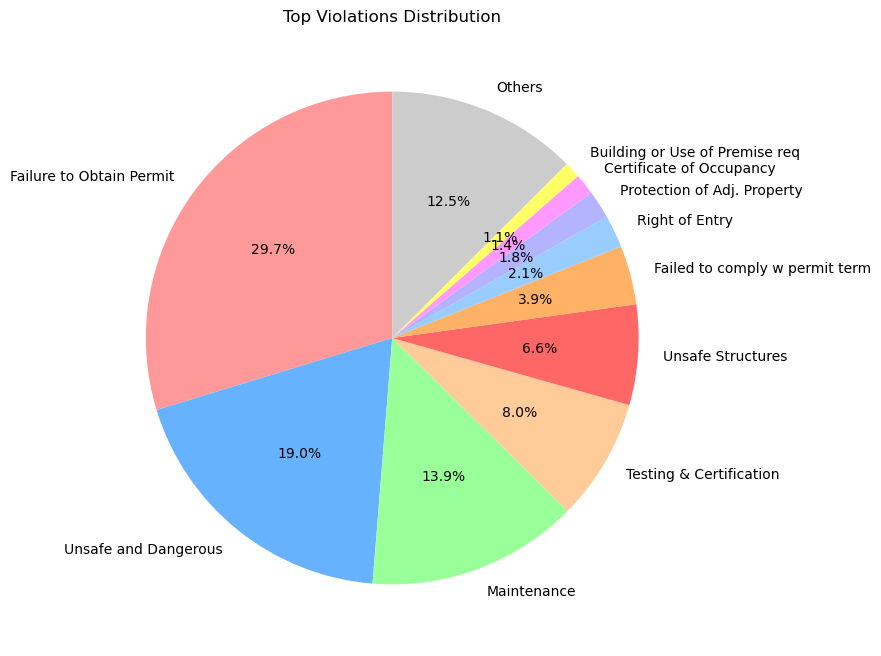

In [44]:
# Pie Chart of number of each violation
import matplotlib.pyplot as plt

# Count the occurrences of each violation
violation_counts = df4['description'].value_counts()

# Optionally limit to top N violations (e.g., top 10), combining others
top_n = 10
violation_top = violation_counts.nlargest(top_n)
violation_top['Others'] = violation_counts[top_n:].sum()

colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF6666', '#FFB266', 
          '#99CCFF', '#B3B3FF', '#FF99FF', '#FFFF66', '#CCCCCC']

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(violation_top, labels=violation_top.index, autopct='%1.1f%%', startangle=90, colors = colors)
plt.title('Top Violations Distribution')
plt.show()

In [46]:
unique_entries = df4['description'].nunique()
(unique_entries)

215

In [49]:
df4['code'].value_counts()

code
105.1                         2159
102.8                          928
116.2                          693
116.1                          667
1001.3.2                       582
                              ... 
1012.6                           1
Art. 15 Adopts Chp. 110.26       1
110-26 (A)                       1
110.3.1                          1
1604.3                           1
Name: count, Length: 255, dtype: int64

In [52]:
temp = df4['sam_id'].apply(lambda x: len(str(x)) if not x is None else False)
temp.value_counts()

sam_id
7    3612
8    3348
6     277
3      45
5      36
4      12
Name: count, dtype: int64